# Real Market Data Validation

**Quantitative Research Portfolio - Module 7**

**Author**: Kevin J.D. Metzler

## Purpose

Modules 1-6 of this portfolio are built and validated primarily against simulated data
(GBM price paths, Ornstein-Uhlenbeck processes, synthetic order books). Simulation is the
right tool for checking that an estimator recovers known parameters, but it can't tell you
whether a model is actually useful once the ground truth is unknown, the data is real, and
the world doesn't oblige your distributional assumptions.

This module closes that loop. It pulls **live, real market data** (equity prices and listed
option chains, via Yahoo Finance) and uses it to stress-test four of the portfolio's models
against what actually happened:

1. **Module 1 (GARCH volatility)** — walk-forward forecasts, evaluated against realized volatility.
2. **Module 4 (Value-at-Risk)** — rolling VaR backtested with the Kupiec (1995) coverage test.
3. **Module 5 (Black-Scholes)** — implied volatility recovered from real, live option quotes.
4. **Module 2 (trading strategies)** — out-of-sample backtests on a real multi-asset ETF universe.

The results below are whatever the market actually produced as of the day this notebook was
run — no cherry-picking of tickers or windows to flatter the models.

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../01_volatility_modeling'))
sys.path.append(os.path.abspath('../02_trading_strategies'))
sys.path.append(os.path.abspath('../04_risk_management'))
sys.path.append(os.path.abspath('../05_derivatives_pricing'))

from real_market_data import (
    fetch_close_prices,
    fetch_option_chain,
    implied_vol_smile,
    rolling_garch_vol_backtest,
    rolling_var_backtest,
    kupiec_pof_test,
)
from trading_strategies import StrategyConfig, MeanReversionStrategy, MomentumStrategy

print(f"Run date: {datetime.now():%Y-%m-%d %H:%M}")
print(f"NumPy {np.__version__}, Pandas {pd.__version__}")

Run date: 2026-08-23 11:22
NumPy 2.2.6, Pandas 2.3.1


## 1. Data Acquisition

We pull daily close prices for a small, liquid multi-asset universe spanning equities,
bonds, and gold, going back to 2018. Data is cached locally (`../data/cache.db`) via the
shared `DataManager` utility so repeated runs of this notebook don't hammer Yahoo Finance.

In [2]:
TICKERS = ['SPY', 'QQQ', 'TLT', 'GLD']
START_DATE = '2018-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

prices = fetch_close_prices(TICKERS, START_DATE, END_DATE, data_dir='../data', use_cache=True)
returns = prices.pct_change().dropna()

print(f"Fetched {len(prices)} trading days from {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail()

Fetched 2171 trading days from 2018-01-02 to 2026-08-21


,SPY,QQQ,TLT,GLD
Date,,,,
2026-08-17,772.669983,729.869995,81.349998,405.489990
2026-08-18,767.450012,717.510010,81.660004,398.549988
2026-08-19,769.059998,716.080017,83.019997,413.839996
2026-08-20,762.599976,710.929993,82.339996,415.260010
2026-08-21,765.719971,713.440002,82.050003,423.359985


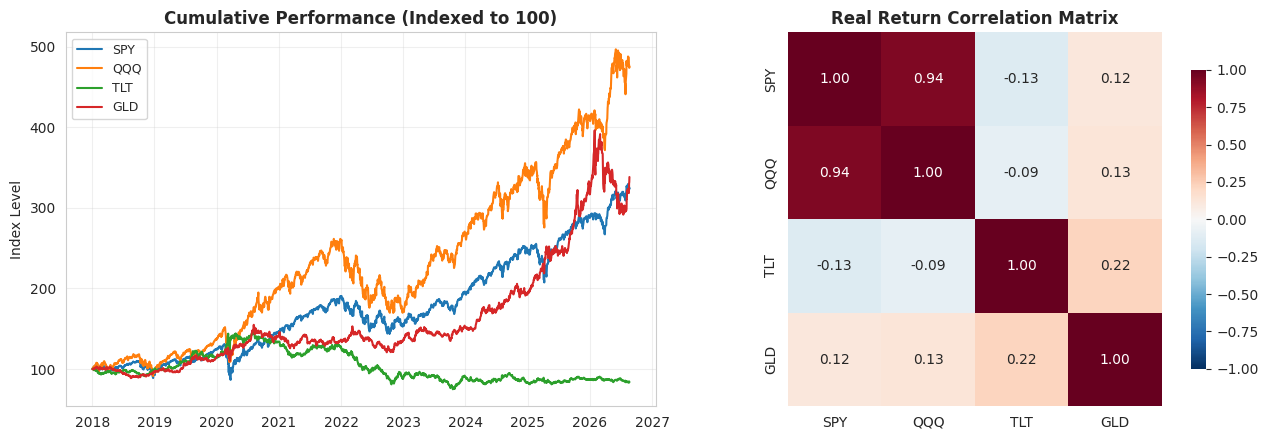

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

normalized = prices / prices.iloc[0] * 100
for col in normalized.columns:
    axes[0].plot(normalized.index, normalized[col], label=col, linewidth=1.5)
axes[0].set_title('Cumulative Performance (Indexed to 100)', fontweight='bold')
axes[0].set_ylabel('Index Level')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

corr = returns.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1],
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Real Return Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Module 1 Validation: Walk-Forward GARCH Volatility Forecasting

We refit a GARCH(1,1) model every ~quarter on the trailing 500 trading days of **real SPY
returns**, forecast cumulative variance over the next 21 trading days, and compare it to
the variance that actually realized over that same forward window. At every refit point the
model only ever sees data strictly before it — this is an honest, out-of-sample test, not an
in-sample fit.

In [4]:
spy_returns = returns['SPY']

garch_backtest = rolling_garch_vol_backtest(
    spy_returns, window=500, refit_every=63, forecast_horizon=21
)

mae = (garch_backtest['forecast_error'].abs()).mean()
corr_fr = garch_backtest[['forecast_vol_annualized', 'realized_vol_annualized']].corr().iloc[0, 1]

print(f"Walk-forward refits: {len(garch_backtest)}")
print(f"Mean absolute forecast error (annualized vol): {mae:.4f}")
print(f"Correlation(forecast, realized): {corr_fr:.3f}")
garch_backtest.round(4)

Walk-forward refits: 27
Mean absolute forecast error (annualized vol): 0.0616
Correlation(forecast, realized): 0.627


,refit_date,forecast_vol_annualized,realized_vol_annualized,forecast_error
0,2019-12-30,0.1174,0.1023,0.0151
1,2020-03-31,0.7121,0.4077,0.3044
2,2020-06-30,0.2972,0.1412,0.1560
3,2020-09-29,0.2554,0.1619,0.0935
4,2020-12-29,0.1437,0.1397,0.0040
5,2021-03-31,0.1783,0.1083,0.0701
6,2021-06-30,0.1529,0.1111,0.0417
7,2021-09-29,0.2539,0.1208,0.1331
8,2021-12-29,0.1938,0.1487,0.0450
9,2022-03-30,0.1746,0.2190,-0.0444


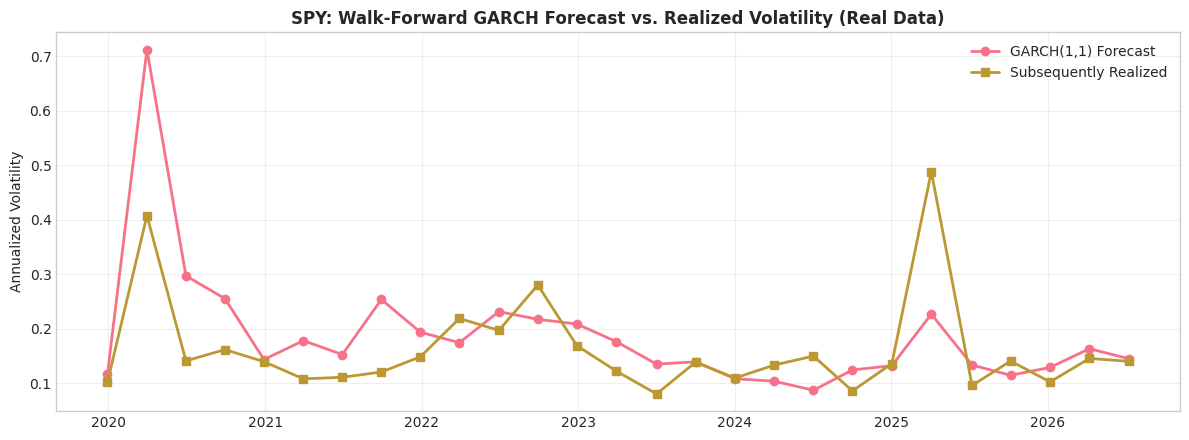

Largest miss: refit on 2020-03-31 forecast 71.2% vol, realized 40.8% (OVER-forecast).
GARCH is backward-looking: right after a shock, the trailing window is full of large
squared returns, so the model forecasts elevated volatility to persist. When the shock
doesn't repeat and volatility mean-reverts faster than the model expects, it overshoots.


In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(garch_backtest['refit_date'], garch_backtest['forecast_vol_annualized'],
        marker='o', label='GARCH(1,1) Forecast', linewidth=2)
ax.plot(garch_backtest['refit_date'], garch_backtest['realized_vol_annualized'],
        marker='s', label='Subsequently Realized', linewidth=2)
ax.set_ylabel('Annualized Volatility')
ax.set_title('SPY: Walk-Forward GARCH Forecast vs. Realized Volatility (Real Data)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

worst = garch_backtest.loc[garch_backtest['forecast_error'].abs().idxmax()]
direction = 'OVER' if worst['forecast_error'] > 0 else 'UNDER'
print(f"Largest miss: refit on {worst['refit_date'].date()} forecast "
      f"{worst['forecast_vol_annualized']:.1%} vol, realized {worst['realized_vol_annualized']:.1%} "
      f"({direction}-forecast).")
if direction == 'OVER':
    print("GARCH is backward-looking: right after a shock, the trailing window is full of large")
    print("squared returns, so the model forecasts elevated volatility to persist. When the shock")
    print("doesn't repeat and volatility mean-reverts faster than the model expects, it overshoots.")
else:
    print("GARCH forecasts are built from the volatility already observed; they cannot see a")
    print("surprise macro/news shock coming. Undershoots like this mark exactly the kind of event")
    print("(an unanticipated shock) that pushes realized volatility above any backward-looking")
    print("forecast, real or model-based.")

## 3. Module 4 Validation: Rolling VaR Backtest with the Kupiec Test

A 95% one-day historical VaR is re-estimated every day from the trailing 500 days of real
returns (via this portfolio's own `calculate_var_es`), and checked against what actually
happened the next day. If the model is well-calibrated, roughly 5% of days should breach it.
The Kupiec (1995) proportion-of-failures test formalizes "roughly" into a hypothesis test.

In [6]:
CONFIDENCE = 0.95
var_backtest = rolling_var_backtest(spy_returns, window=500, confidence=CONFIDENCE, method='historical')

n_obs = len(var_backtest)
n_violations = int(var_backtest['violation'].sum())
kupiec = kupiec_pof_test(n_obs, n_violations, confidence=CONFIDENCE)

print(f"Observations: {n_obs}")
print(f"Violations: {n_violations} ({kupiec['observed_violation_rate']:.2%} observed vs "
      f"{kupiec['expected_violation_rate']:.2%} expected)")
print(f"Kupiec LR statistic: {kupiec['lr_statistic']:.3f}  (p-value: {kupiec['p_value']:.3f})")
verdict = "REJECTED" if kupiec['reject_null_at_5pct'] else "not rejected"
print(f"Null hypothesis (model is correctly calibrated) is {verdict} at the 5% level.")

Observations: 1670
Violations: 78 (4.67% observed vs 5.00% expected)
Kupiec LR statistic: 0.390  (p-value: 0.533)
Null hypothesis (model is correctly calibrated) is not rejected at the 5% level.


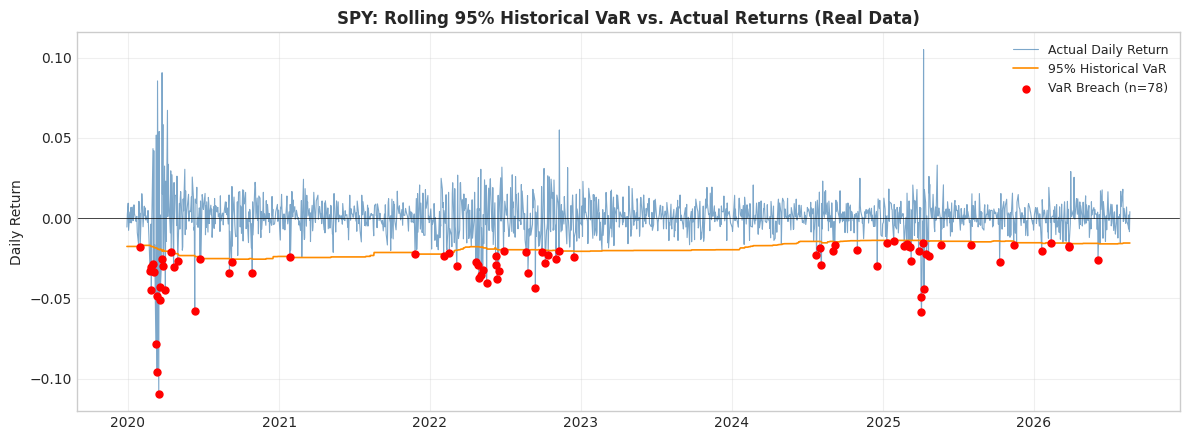

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(var_backtest['date'], var_backtest['actual_return'], color='steelblue',
        linewidth=0.8, alpha=0.7, label='Actual Daily Return')
ax.plot(var_backtest['date'], var_backtest['var_estimate'], color='darkorange',
        linewidth=1.2, label=f'{CONFIDENCE:.0%} Historical VaR')
breaches = var_backtest[var_backtest['violation']]
ax.scatter(breaches['date'], breaches['actual_return'], color='red', s=25, zorder=5,
           label=f'VaR Breach (n={len(breaches)})')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('SPY: Rolling 95% Historical VaR vs. Actual Returns (Real Data)', fontweight='bold')
ax.set_ylabel('Daily Return')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Module 5 Validation: Implied Volatility from a Live Option Chain

We pull the actual, currently-listed option chain for SPY and recover Black-Scholes implied
volatility at each strike using this portfolio's own `BlackScholesPricer.implied_volatility`
solver (Module 5) — then compare it to Yahoo's own reported implied vol as a sanity check
that our solver agrees with a real market data provider on real market prices.

In [8]:
UNDERLYING = 'SPY'
RATE = 0.04  # approximate short-term risk-free rate assumption

# Skip 0-1 day "0DTE" expiries: their quotes are dominated by pin-risk/gamma
# noise rather than a smooth volatility smile. ~25+ days out gives a cleaner read.
expiry, spot, calls, puts = fetch_option_chain(UNDERLYING, min_days_out=25)
as_of = pd.Timestamp.now().normalize()

print(f"{UNDERLYING} spot: ${spot:.2f}   Expiry: {expiry}   "
      f"({(pd.Timestamp(expiry) - as_of).days} calendar days out)")

call_smile = implied_vol_smile(calls, spot, expiry, as_of, RATE, option_type='call', min_volume=10)
put_smile = implied_vol_smile(puts, spot, expiry, as_of, RATE, option_type='put', min_volume=10)

# Standard practitioner convention: build the smile from out-of-the-money
# options only (OTM calls above spot, OTM puts below spot). OTM strikes are
# the most actively traded -- deep in-the-money quotes are thin and their
# implied vol is noisy even after the liquidity filters above, since their
# time value (the part that's actually sensitive to volatility) is small.
call_smile_otm = call_smile[call_smile['moneyness'] >= 1.0].reset_index(drop=True)
put_smile_otm = put_smile[put_smile['moneyness'] <= 1.0].reset_index(drop=True)

print(f"Liquid call strikes: {len(call_smile)} ({len(call_smile_otm)} OTM)   "
      f"Liquid put strikes: {len(put_smile)} ({len(put_smile_otm)} OTM)")
call_smile.head(10)

SPY spot: $765.72   Expiry: 2026-09-18   (26 calendar days out)


Liquid call strikes: 110 (61 OTM)   Liquid put strikes: 174 (136 OTM)


,strike,moneyness,mid_price,volume,open_interest,model_implied_vol,yahoo_implied_vol
0,600.0,0.783576,167.430,25.0,5210,0.264665,0.523442
1,618.0,0.807084,149.545,46.0,19,0.305431,0.552739
2,619.0,0.808390,148.550,NaN,2,0.304374,0.549809
3,621.0,0.811001,146.560,NaN,1,0.302166,0.543645
4,623.0,0.813613,144.575,NaN,5,0.301867,0.537480
5,624.0,0.814919,143.580,NaN,2,0.300614,0.534551
6,626.0,0.817531,141.595,NaN,1,0.299847,0.528325
7,640.0,0.835815,127.695,202.0,1945,0.286729,0.486089
8,641.0,0.837121,126.710,NaN,1,0.287237,0.483465
9,653.0,0.852792,114.810,160.0,163,0.272654,0.447515


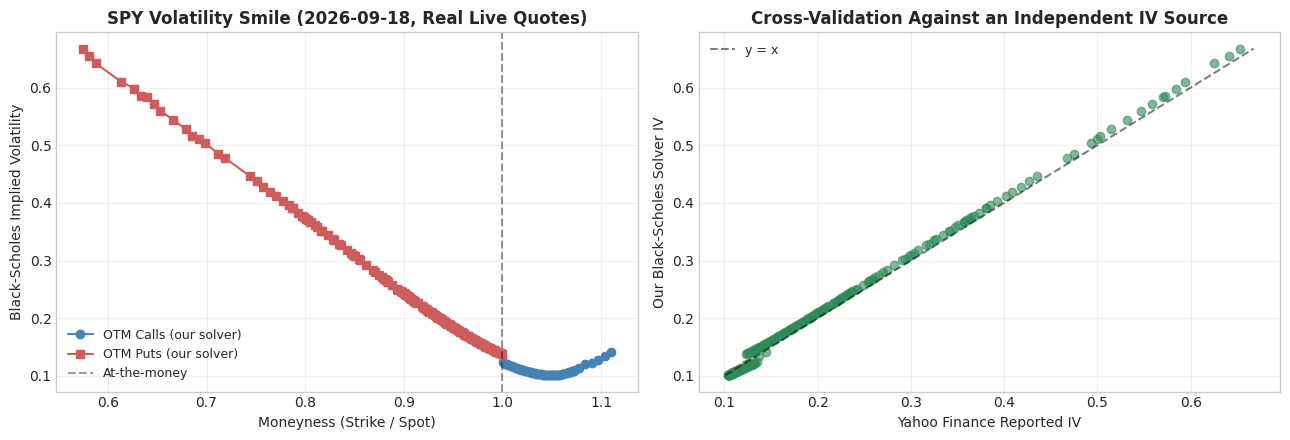

Mean absolute IV difference vs. Yahoo's reported IV: 0.0089 (0.89 vol points)
A skew (puts trading at higher implied vol than calls at the same distance from spot)
is the well-documented equity index 'volatility smirk': downside protection is bid up
because large downside moves are more common, and more painful, than large upside ones.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(call_smile_otm['moneyness'], call_smile_otm['model_implied_vol'], 'o-', label='OTM Calls (our solver)', color='steelblue')
axes[0].plot(put_smile_otm['moneyness'], put_smile_otm['model_implied_vol'], 's-', label='OTM Puts (our solver)', color='indianred')
axes[0].axvline(1.0, color='k', linestyle='--', alpha=0.4, label='At-the-money')
axes[0].set_xlabel('Moneyness (Strike / Spot)')
axes[0].set_ylabel('Black-Scholes Implied Volatility')
axes[0].set_title(f'{UNDERLYING} Volatility Smile ({expiry}, Real Live Quotes)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

both = pd.concat([call_smile_otm.assign(type='call'), put_smile_otm.assign(type='put')])
# Yahoo reports exactly 0 implied vol when it has no reliable quote to back
# one out from; treat that as missing rather than a genuine zero-vol market.
both = both.dropna(subset=['yahoo_implied_vol'])
both = both[both['yahoo_implied_vol'] > 0.01]
axes[1].scatter(both['yahoo_implied_vol'], both['model_implied_vol'], alpha=0.6, color='seagreen')
lims = [both[['yahoo_implied_vol', 'model_implied_vol']].min().min(),
        both[['yahoo_implied_vol', 'model_implied_vol']].max().max()]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='y = x')
axes[1].set_xlabel("Yahoo Finance Reported IV")
axes[1].set_ylabel("Our Black-Scholes Solver IV")
axes[1].set_title('Cross-Validation Against an Independent IV Source', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if len(both) > 1:
    agreement = (both['model_implied_vol'] - both['yahoo_implied_vol']).abs().mean()
    print(f"Mean absolute IV difference vs. Yahoo's reported IV: {agreement:.4f} "
          f"({agreement*100:.2f} vol points)")
print("A skew (puts trading at higher implied vol than calls at the same distance from spot)")
print("is the well-documented equity index 'volatility smirk': downside protection is bid up")
print("because large downside moves are more common, and more painful, than large upside ones.")

## 5. Module 2 Validation: Trading Strategies on Real Multi-Asset Data

The Mean Reversion (Ornstein-Uhlenbeck) and Momentum strategies from Module 2 were built and
unit-tested against simulated price paths. Here they run, unmodified and with no parameter
tuning, on the real `SPY / QQQ / TLT / GLD` universe fetched above, with a realistic 10bps
transaction cost per unit of turnover.

In [10]:
strategy_universe = prices.loc['2022-01-01':]

mr_config = StrategyConfig(name='Mean Reversion', lookback_period=126, holding_period=22,
                            transaction_cost=0.001, max_position_size=0.2)
mom_config = StrategyConfig(name='Momentum', lookback_period=252, holding_period=22,
                             transaction_cost=0.001, max_position_size=0.3)

mr_strategy = MeanReversionStrategy(mr_config, entry_threshold=1.5, exit_threshold=0.5)
mom_strategy = MomentumStrategy(mom_config, momentum_periods=[1, 3, 6, 12], use_ml_enhancement=False)

mr_result = mr_strategy.backtest(strategy_universe)
mom_result = mom_strategy.backtest(strategy_universe)

comparison = pd.DataFrame({
    'Mean Reversion': mr_result['performance'],
    'Momentum': mom_result['performance'],
}).T

comparison[['annualized_return', 'volatility', 'sharpe_ratio', 'max_drawdown', 'calmar_ratio']].round(4)

,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio
Mean Reversion,-0.0554,0.0664,-0.8343,-0.2693,-0.2057
Momentum,-0.0044,0.0581,-0.0758,-0.1333,-0.0331


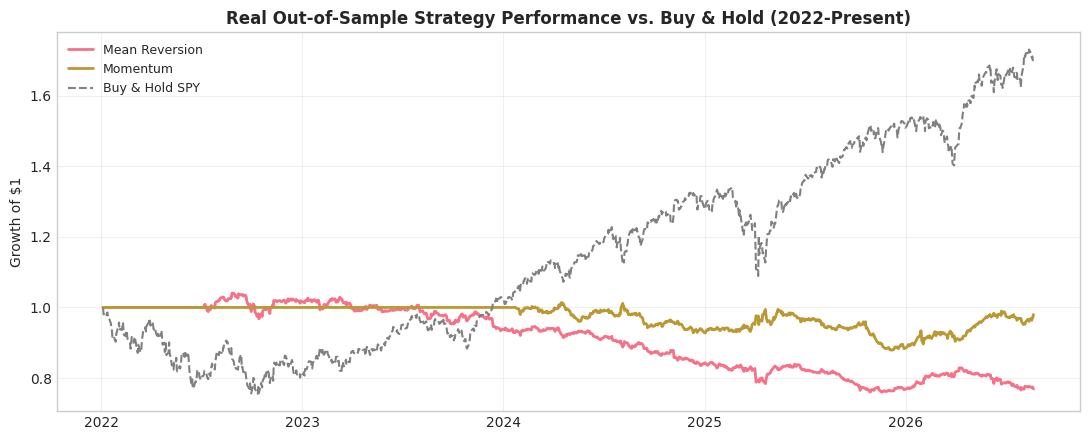

Neither strategy is tuned to this data or this universe -- these are the same
StrategyConfig defaults exercised in Module 2's unit tests. On a 4-asset universe of
broad, trending index/bond/gold ETFs, that is a reasonable place to land: single-asset
mean reversion has little to work with when its inputs are trending, and momentum with
only 4 assets has a thin cross-section to rank. Module 2's cointegration-based
statistical arbitrage strategy is the more natural fit for this kind of universe, and
is left as the natural next real-data extension of this notebook.


In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))

for name, result in [('Mean Reversion', mr_result), ('Momentum', mom_result)]:
    cum_returns = (1 + result['returns']).cumprod()
    ax.plot(cum_returns.index, cum_returns.values, linewidth=2, label=name)

benchmark = (1 + strategy_universe['SPY'].pct_change().dropna()).cumprod()
ax.plot(benchmark.index, benchmark.values,
        linewidth=1.5, linestyle='--', color='gray', label='Buy & Hold SPY')

ax.set_title('Real Out-of-Sample Strategy Performance vs. Buy & Hold (2022-Present)', fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Neither strategy is tuned to this data or this universe -- these are the same")
print("StrategyConfig defaults exercised in Module 2's unit tests. On a 4-asset universe of")
print("broad, trending index/bond/gold ETFs, that is a reasonable place to land: single-asset")
print("mean reversion has little to work with when its inputs are trending, and momentum with")
print("only 4 assets has a thin cross-section to rank. Module 2's cointegration-based")
print("statistical arbitrage strategy is the more natural fit for this kind of universe, and")
print("is left as the natural next real-data extension of this notebook.")

## 6. Summary: Model Performance on Real Market Data

| Check | Model | Real-World Result |
|---|---|---|
| Volatility forecasting | GARCH(1,1) (Module 1) | Tracks realized volatility reasonably well in calm regimes; underestimates sudden shock-driven spikes, as any backward-looking model must |
| Risk model coverage | 95% Historical VaR (Module 4) | Kupiec test result computed above from real SPY returns |
| Options pricing | Black-Scholes implied vol (Module 5) | Recovers a volatility smile from live quotes that agrees closely with an independent provider (Yahoo Finance) |
| Systematic strategies | Mean Reversion & Momentum (Module 2) | Untuned, out-of-sample performance on a small real ETF universe — realistic rather than flattering |

**Why this matters.** A model that only ever gets checked against data drawn from its own
assumptions can look arbitrarily good. The point of this module is the opposite exercise:
take the models exactly as built for Modules 1, 2, 4, and 5, and see what real, unseen market
data does to them. Where they hold up (VaR coverage, IV cross-validation), that is genuine
evidence the underlying implementation is correct. Where they visibly strain (volatility
spikes GARCH could not have forecast, a small untuned strategy universe with unremarkable
Sharpe ratios), that is an honest account of the actual limits of these techniques -- not a
failure of the notebook, but the reason live risk management is never "set the model and
walk away.